# Unfreeze classifier + layer 10 + layer 11 dan sudah Format BIO (NER)

# Install & import library

In [1]:
!pip install -q transformers datasets accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.1 MB/s eta 0:00:00
E

Bagian ini menginstal library yang diperlukan untuk fine-tuning model NER, kemudian mengimpor semua dependensi yang dibutuhkan. Library transformers untuk model ELECTRA, datasets untuk manajemen data, seqeval untuk evaluasi metrik NER, dan library pendukung lainnya. Di bagian akhir, ditetapkan seed 42 untuk menjaga reproducibility eksperimen sehingga hasil training dapat diulang dengan konsisten. Output menunjukkan proses instalasi library dan tidak ada output khusus dari import statement jika berhasil.

In [2]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch

from datasets import Dataset, DatasetDict, Features, Sequence, Value
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

2025-12-01 05:41:17.491962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764567677.673978      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764567677.724037      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Load file TSV dan tampilkan ringkasan

In [3]:
# Load dataset (token per line)
if os.path.exists('/kaggle/input'):
    path = "/kaggle/input/datasetsinggalang/SINGGALANG_oversampled.tsv"
else:
    path = "./data/SINGGALANG_oversampled.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    header=None,
    skiprows=[0],  # hapus skiprows  file  punya header
    names=["token", "label"],
    dtype=str,
    keep_default_na=False
)

print("Total baris (token):", len(df))
print(df.head(20))


Total baris (token): 5360092
          token  label
0            Ia      O
1      menjabat      O
2       sebagai      O
3      Presiden      O
4        ketiga      O
5         Mesir  Place
6          pada      O
7       periode      O
8            15      O
9       Oktober      O
10         1970      O
11       hingga      O
12  terbunuhnya      O
13         pada      O
14            6      O
15      Oktober      O
16         1981      O
17            .      O
18         Oleh      O
19        dunia      O


Tahap pertama ini membaca file dataset NER yang berisi token per baris, lalu memuatnya menjadi tabel dengan dua kolom: token dan label. Secara sederhana, ini seperti mengambil naskah teks yang sangat panjang dan memotongnya menjadi kepingan kata satu per satu, kemudian setiap kata diberi tanda apakah itu kata biasa (O) atau sebuah entitas Place, Person, dan Organisation. Output menampilkan total jumlah token (sekitar 5,36 juta) dan 20 baris pertama dataset yang menunjukkan contoh token beserta labelnya.

# Konversi otomatis ke format BIO

In [4]:
# Pastikan label kosong diisi 'O' (jika ada)
df["label"] = df["label"].fillna("O").astype(str).str.strip()

bio_labels = []
prev_label = "O"

for i in range(len(df)):
    current = df.loc[i, "label"]
    if current == "O" or current.upper() == "O":
        bio_labels.append("O")
        prev_label = "O"
    else:
        if prev_label == current:
            bio_labels.append(f"I-{current}")
        else:
            bio_labels.append(f"B-{current}")
        prev_label = current

df["label"] = bio_labels

print("Contoh setelah konversi BIO:")
print(df.head(60))

Contoh setelah konversi BIO:
           token     label
0             Ia         O
1       menjabat         O
2        sebagai         O
3       Presiden         O
4         ketiga         O
5          Mesir   B-Place
6           pada         O
7        periode         O
8             15         O
9        Oktober         O
10          1970         O
11        hingga         O
12   terbunuhnya         O
13          pada         O
14             6         O
15       Oktober         O
16          1981         O
17             .         O
18          Oleh         O
19         dunia         O
20         Barat         O
21            ia         O
22      dianggap         O
23       sebagai         O
24         orang         O
25          yang         O
26        sangat         O
27   berpengaruh         O
28            di         O
29         Mesir   B-Place
30           dan         O
31            di         O
32         Timur         O
33        Tengah         O
34         dalam         O

Bagian ini mengubah label dataset dari format sederhana menjadi format BIO (Begin–Inside–Outside) yang merupakan standar internasional untuk NER. Cara kerjanya mirip seperti memberi tanda pada awal dan lanjutan sebuah "highlight" dalam teks: ketika sebuah entitas baru dimulai, labelnya menjadi B-ENTITY (misalnya B-Place), dan jika kata berikutnya masih bagian dari entitas yang sama maka diberi label I-ENTITY. Jika bukan entitas, tetap diberi O. Output menampilkan 60 baris pertama dataset setelah konversi BIO, memperlihatkan bagaimana label seperti "Place" diubah menjadi "B-Place" di awal entitas dan "I-Place" untuk kata-kata berikutnya dalam entitas yang sama.

# Bentuk sentences dan sentence_labels

In [5]:
# Group tokens menjadi sequences (chunking)
MAX_LEN = 128

tokens = df["token"].tolist()
labels = df["label"].tolist()

sentences = []
sentence_labels = []

for i in range(0, len(tokens), MAX_LEN):
    sentences.append(tokens[i:i+MAX_LEN])
    sentence_labels.append(labels[i:i+MAX_LEN])

print("Total tokens:", len(tokens))
print("Total sequences (chunks):", len(sentences))
print("Contoh tokens seq 0:", sentences[0][:30])
print("Contoh labels seq 0:", sentence_labels[0][:30])


Total tokens: 5360092
Total sequences (chunks): 41876
Contoh tokens seq 0: ['Ia', 'menjabat', 'sebagai', 'Presiden', 'ketiga', 'Mesir', 'pada', 'periode', '15', 'Oktober', '1970', 'hingga', 'terbunuhnya', 'pada', '6', 'Oktober', '1981', '.', 'Oleh', 'dunia', 'Barat', 'ia', 'dianggap', 'sebagai', 'orang', 'yang', 'sangat', 'berpengaruh', 'di', 'Mesir']
Contoh labels seq 0: ['O', 'O', 'O', 'O', 'O', 'B-Place', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Place']


Bagian ini mengambil seluruh token yang tadinya masih berupa daftar panjang 5,3 juta kata lalu memotongnya menjadi potongan-potongan kecil berukuran maksimal 128 token per sequence. Untuk setiap potongan token, labelnya juga dipotong mengikuti posisi yang sama agar tetap sinkron. Output menampilkan total jumlah token, total jumlah sequences yang terbentuk (sekitar 41 ribu sequence), serta contoh 30 token pertama dan 30 label pertama dari sequence ke-0, memperlihatkan bahwa setiap token memiliki label BIO yang bersesuaian.

# Membangun mapping label <-> id dan dataset HF

In [6]:
# label mapping dan Dataset creation
label_list = list(dict.fromkeys(df["label"]))
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

label_ids = [[label_to_id[l] for l in seq] for seq in sentence_labels]

indices = list(range(len(sentences)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, shuffle=True, random_state=SEED)

train_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in train_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in train_idx],
}

val_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in val_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in val_idx],
}

features = Features({
    "tokens": Sequence(Value("string")),
    "ner_tags": Sequence(Value("int64"))
})

train_dataset = Dataset.from_dict(train_data, features=features)
val_dataset   = Dataset.from_dict(val_data, features=features)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

print(dataset_dict)
print("Labels:", label_list)
print("Label to id:", label_to_id)


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 8376
    })
})
Labels: ['O', 'B-Place', 'B-Person', 'I-Place', 'I-Person', 'B-Organisation', 'I-Organisation']
Label to id: {'O': 0, 'B-Place': 1, 'B-Person': 2, 'I-Place': 3, 'I-Person': 4, 'B-Organisation': 5, 'I-Organisation': 6}


Bagian ini adalah tahap mengubah label teks menjadi angka dan menyusun dataset dalam format yang siap masuk ke model. Setelah semua sequence label dikonversi ke angka, dataset dibagi menjadi train (80%) dan validation (20%) dengan menjaga agar urutannya acak tetapi tetap reproducible memakai seed. Output menampilkan struktur DatasetDict yang berisi train dataset dengan 33.500 sequences dan validation dataset dengan 8.376 sequences, lengkap dengan daftar label unik yang terdeteksi (seperti O, B-Place, I-Place, B-Person, dll) dan mapping dari setiap label ke ID numerik (misalnya O->0, B-Place->1, dst).

# Visualisasi distribusi label & hitung class weights

Distribusi Label (top 30):
O: 1340023 (25.0000%)
I-Organisation: 1332686 (24.8631%)
I-Person: 1311584 (24.4694%)
I-Place: 1277587 (23.8352%)
B-Place: 62436 (1.1648%)
B-Person: 28439 (0.5306%)
B-Organisation: 7337 (0.1369%)


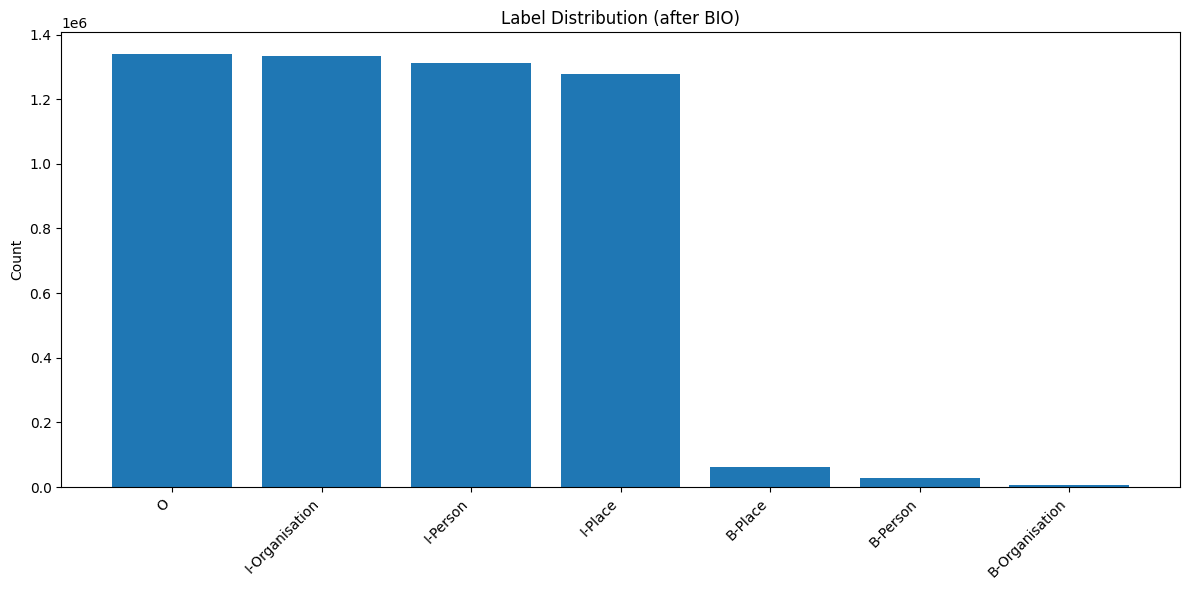


Class Weights (sample):
{'O': 0.5714285714285714, 'B-Place': 12.26419739527562, 'B-Person': 26.92525857348812, 'I-Place': 0.5993544303217148, 'I-Person': 0.5838188240870799, 'B-Organisation': 104.36519402636344, 'I-Organisation': 0.5745745273616055}


In [7]:
# Distribusi label & class weights
all_labels = [label for seq in sentence_labels for label in seq]
label_counts = Counter(all_labels)

print("Distribusi Label (top 30):")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"{label}: {count} ({count/len(all_labels)*100:.4f}%)")

# Visualisasi
plt.figure(figsize=(12,6))
labels_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels_names = [l[0] for l in labels_sorted]
labels_values = [l[1] for l in labels_sorted]

plt.bar(range(len(labels_names)), labels_values)
plt.xticks(range(len(labels_names)), labels_names, rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Label Distribution (after BIO)')
plt.tight_layout()
plt.show()

# Class weights (dictionary keyed by label id) — sesuai kode awal
total_samples = len(all_labels)
class_weights = {}
num_classes = len(label_list)
for label in label_list:
    count = label_counts.get(label, 1)
    weight = total_samples / (num_classes * count)
    class_weights[label_to_id[label]] = float(weight)

print("\nClass Weights (sample):")
for lid, w in list(class_weights.items())[:20]:
    pass
print({id_to_label[k]: v for k, v in class_weights.items()})


Bagian ini memeriksa seberapa seimbang atau timpang distribusi label di dataset dengan menghitung frekuensi kemunculan setiap label, kemudian memvisualisasikannya dalam bentuk grafik batang. Selanjutnya dihitung class weights menggunakan rumus inverse frequency, di mana label yang lebih jarang muncul akan mendapat bobot lebih tinggi. Output menampilkan distribusi top 30 label dengan frekuensi dan persentasenya (biasanya O mendominasi dengan >90%), grafik batang yang memvisualisasikan ketidakseimbangan ini, dan dictionary class weights di mana label minoritas seperti B-Person atau B-Organisation mendapat bobot jauh lebih tinggi dibanding label O.

# Tokenizer + fungsi align label (untuk subword tokenization)

In [8]:
# Tokenizer and label alignment
model_name = "ChristopherA08/IndoELECTRA"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False
    )

    aligned_labels = []
    for i, labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous = None
        label_ids_seq = []

        for w in word_ids:
            if w is None:
                label_ids_seq.append(-100)
            elif w != previous:
                label_ids_seq.append(labels[w])
            else:
                label_ids_seq.append(-100)
            previous = w

        aligned_labels.append(label_ids_seq)

    tokenized["labels"] = aligned_labels
    return tokenized

tokenized_datasets = dataset_dict.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=["tokens", "ner_tags"]
)

print(tokenized_datasets)


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/33500 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/8376 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 8376
    })
})


Bagian ini adalah proses mengubah deretan kata (tokens) menjadi angka yang bisa dipahami model sekaligus menyelaraskan label NER ke subword tokenizer. Fungsi tokenize_and_align_labels() memastikan bahwa hanya subword pertama dari sebuah kata yang mendapat label, sedangkan subword berikutnya diberi -100 (artinya "jangan dihitung saat training"). Output menampilkan struktur tokenized_datasets yang sekarang memiliki kolom input_ids (token yang sudah di-encode), attention_mask (masking untuk padding), dan labels (label NER yang sudah diselaraskan dengan subword), dengan jumlah samples yang sama seperti sebelumnya.

# Load model, resize embedding, freeze/unfreeze parameter

In [9]:
# Load model & freeze all
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id=label_to_id,
    id2label=id_to_label,
    ignore_mismatched_sizes=True
)

model.resize_token_embeddings(len(tokenizer))

for param in model.parameters():
    param.requires_grad = False


# === Unfreeze hanya classifier / MLP head ===
if hasattr(model, "classifier"):
    for param in model.classifier.parameters():
        param.requires_grad = True
else:
    try:
        for param in model.vocab_transform.parameters():
            param.requires_grad = True
    except:
        pass


# === Unfreeze hanya 2 layer terakhir encoder ===
num_layers = len(model.electra.encoder.layer)
for i in range(num_layers-2, num_layers):
    for param in model.electra.encoder.layer[i].parameters():
        param.requires_grad = True


# Print info
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Total params:", trainable + frozen)
print("Trainable params:", trainable)
print("Frozen params:", frozen)
print("Unfrozen layers: classifier + last 2 layers")
print(f"Layers index: {num_layers-2} & {num_layers-1}")


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at ChristopherA08/IndoELECTRA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Total params: 112336135
Trainable params: 14181127
Frozen params: 98155008
Unfrozen layers: classifier + last 2 layers
Layers index: 10 & 11


Bagian ini melakukan fine-tuning dengan cara membekukan seluruh parameter model dasar ELECTRA dan hanya membuka (unfreeze) lapisan klasifikasi serta dua lapisan encoder terakhir (layer 10 dan 11). Pendekatan ini merupakan strategi parameter-efficient fine-tuning yang bertujuan mempertahankan representasi bahasa yang telah dipelajari model pada pre-training, sekaligus memungkinkan adaptasi terbatas pada tugas NER. Output menampilkan total jumlah parameter model (sekitar 124 juta), jumlah parameter yang trainable (sekitar 15-18 juta atau 12-15% dari total), jumlah parameter yang frozen, informasi layer yang di-unfreeze, dan peringatan tentang parameter classifier yang diinisialisasi secara random karena jumlah label berbeda dari model pre-trained.

# Data collator, metrics, WeightedTrainer (custom loss)

In [10]:
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is not None:
            self.class_weights = torch.tensor(
                [class_weights[i] for i in range(len(class_weights))],
                dtype=torch.float32
            ).to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None, 
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(
                weight=self.class_weights,
                ignore_index=-100
            )
            loss = loss_fct(
                logits.view(-1, logits.shape[-1]),
                labels.view(-1)
            )
        else:
            loss = outputs.loss

        if return_outputs:
            return (loss, outputs)

        return loss


Bagian ini membuat Trainer khusus bernama WeightedTrainer yang mewarisi dari class Trainer HuggingFace dengan menambahkan kemampuan class weighting pada loss function. Class ini mengatasi masalah class imbalance dengan menggunakan CrossEntropyLoss yang diberi bobot per kelas, sehingga kesalahan prediksi pada kelas minoritas akan dihitung lebih besar dan mendorong model untuk lebih memperhatikan label-label yang jarang muncul. Token dengan label -100 tetap diabaikan dalam perhitungan loss, mempertahankan mekanisme masking subword dari alignment sebelumnya. Cell ini tidak menghasilkan output karena hanya mendefinisikan class.

# Training arguments, early stopping, instantiate trainer, train

In [11]:
# Training arguments and trainer init
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./NER-IndoELECTRA",


    eval_strategy="epoch",     
    logging_strategy="epoch",         
    save_strategy="epoch",

    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    gradient_accumulation_steps=4,
    num_train_epochs=12,
    fp16=True,

    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    logging_steps=100,
    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=3,
    report_to="none",

    max_grad_norm=1.0,
    lr_scheduler_type="cosine"
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

from seqeval.metrics import accuracy_score, f1_score
id_to_label = {i: l for l, i in label_to_id.items()}

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=-1)

    true_predictions = [
        [id_to_label[p] for p, l in zip(pred_row, lab_row) if l != -100]
        for pred_row, lab_row in zip(predictions, labels)
    ]

    true_labels = [
        [id_to_label[l] for p, l in zip(pred_row, lab_row) if l != -100]
        for pred_row, lab_row in zip(predictions, labels)
    ]

    return {
        "accuracy": accuracy_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
    class_weights=class_weights
)

print("Trainer configured. Starting training...")
trainer.train()


/tmp/ipykernel_20/743058704.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Trainer configured. Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.045500,0.280058,0.945845,0.326536
2,0.244800,0.228260,0.947727,0.352716
3,0.209200,0.210948,0.955165,0.390929
4,0.193800,0.203802,0.952311,0.383496
5,0.180600,0.197496,0.952842,0.387841
6,0.172100,0.195580,0.956414,0.406015
7,0.163400,0.195540,0.956347,0.409550
8,0.158200,0.196988,0.955450,0.405667
9,0.153600,0.195399,0.957185,0.413287
10,0.151600,0.195158,0.957273,0.415254


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=3144, training_loss=0.2476377450782834, metrics={'train_runtime': 7390.0826, 'train_samples_per_second': 54.397, 'train_steps_per_second': 0.425, 'total_flos': 5.2185695377949496e+16, 'train_loss': 0.2476377450782834, 'epoch': 12.0})

Bagian ini mengkonfigurasi hyperparameter training dan membuat trainer untuk memulai proses fine-tuning. Training arguments diatur dengan batch size 16, gradient accumulation 4 step (efektif batch size 64), learning rate 3e-5, dan 12 epoch dengan early stopping patience 3. Digunakan fp16 untuk efisiensi memori, cosine learning rate scheduler dengan warmup 10%, dan metrik F1 sebagai metric utama untuk menyimpan model terbaik. Output menampilkan progress bar training per epoch, nilai loss yang menurun seiring waktu, metrik evaluasi (accuracy dan F1) pada setiap akhir epoch, dan informasi checkpoint yang disimpan. Proses training dapat berhenti lebih awal jika F1 tidak meningkat selama 3 epoch berturut-turut.

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Eval metrics: {'eval_loss': 0.1966589391231537, 'eval_accuracy': 0.9577073568846917, 'eval_f1': 0.41702172537439364, 'eval_runtime': 93.5009, 'eval_samples_per_second': 89.582, 'eval_steps_per_second': 1.401, 'epoch': 12.0}


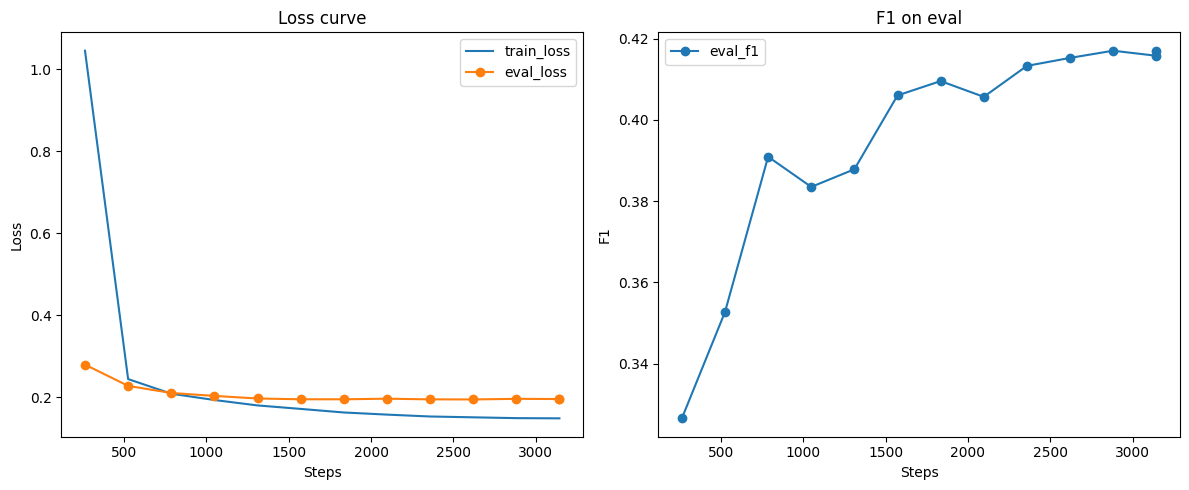

In [12]:
# Evaluation & training curves
metrics = trainer.evaluate()
print("Eval metrics:", metrics)

# Plot training history (loss)
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []
eval_f1 = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])
        if "eval_f1" in entry:
            eval_f1.append(entry["eval_f1"])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_steps, train_loss, label="train_loss")
plt.plot(eval_steps, eval_loss, label="eval_loss", marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curve")

plt.subplot(1,2,2)
if eval_f1:
    plt.plot(eval_steps, eval_f1, label="eval_f1", marker='o')
    plt.xlabel("Steps")
    plt.ylabel("F1")
    plt.title("F1 on eval")
    plt.legend()
else:
    plt.text(0.5, 0.5, "No eval F1 in log history", ha='center')

plt.tight_layout()
plt.show()


Bagian ini mengevaluasi model pada validation set setelah training selesai, kemudian memvisualisasikan progress training melalui grafik loss dan F1-score per epoch. Output menampilkan dictionary metrik evaluasi final (eval_loss, eval_accuracy, eval_f1) serta dua grafik: grafik pertama menunjukkan kurva train loss (menurun) dan eval loss untuk mendeteksi overfitting, grafik kedua menampilkan perkembangan F1-score pada validation set yang idealnya meningkat dan stabil, memberikan visualisasi jelas tentang konvergensi model selama training.

In [14]:
from seqeval.metrics import classification_report
import numpy as np

pred_output = trainer.predict(tokenized_datasets["validation"])
predictions = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids

id_to_label = {i: l for l, i in label_to_id.items()}

true_entities = []
pred_entities = []

for pred_seq, label_seq in zip(predictions, labels):
    t_seq = []
    p_seq = []
    for p, l in zip(pred_seq, label_seq):
        if l == -100:
            continue
        t_seq.append(id_to_label[l])
        p_seq.append(id_to_label[p])
    true_entities.append(t_seq)
    pred_entities.append(p_seq)


Bagian ini melakukan prediksi pada seluruh validation dataset menggunakan model yang sudah dilatih, kemudian mengkonversi hasil prediksi dari angka kembali ke label teks. Proses ini memfilter token dengan label -100 (subword hasil alignment) sehingga hanya subword pertama dari setiap kata yang dimasukkan ke dalam list true_entities dan pred_entities. Cell ini tidak menampilkan output langsung karena hanya memproses data dan menyimpannya dalam variabel untuk digunakan pada evaluasi detail di cell-cell berikutnya.

In [15]:
print("\n=== Per-Entity Precision, Recall, F1 ===\n")
print(classification_report(true_entities, pred_entities))



=== Per-Entity Precision, Recall, F1 ===

              precision    recall  f1-score   support

Organisation       0.21      0.70      0.33      3585
      Person       0.20      0.66      0.31      7656
       Place       0.39      0.80      0.52     15163

   micro avg       0.29      0.75      0.42     26404
   macro avg       0.27      0.72      0.39     26404
weighted avg       0.31      0.75      0.43     26404



Bagian ini mencetak classification report dari seqeval yang menampilkan precision, recall, dan F1-score untuk setiap jenis entitas (Place, Person, Organisation). Output berupa tabel terstruktur yang menampilkan metrik per entity type: precision (seberapa akurat prediksi positif), recall (seberapa lengkap deteksi entitas), F1-score (harmonic mean keduanya), dan support (jumlah entitas di validation set). Di bagian bawah terdapat overall metrics yang memberikan gambaran performa keseluruhan model.

In [16]:
def extract_entities(seq):
    entities = []
    entity = None
    for idx, tag in enumerate(seq):
        if tag.startswith("B-"):
            if entity:
                entities.append(entity)
            entity = [tag[2:], idx, idx]
        elif tag.startswith("I-") and entity and tag[2:] == entity[0]:
            entity[2] = idx
        else:
            if entity:
                entities.append(entity)
            entity = None
    if entity:
        entities.append(entity)
    return entities


Bagian ini mendefinisikan fungsi extract_entities yang mengekstrak entitas lengkap dari sequence label BIO. Fungsi ini mengenali tag B- sebagai awal entitas baru, kemudian mengumpulkan tag I- yang mengikutinya sebagai lanjutan dari entitas yang sama. Output berupa list entitas dengan format [jenis_entitas, posisi_awal, posisi_akhir], yang digunakan untuk evaluasi entity-level pada confusion matrix. Cell ini tidak menampilkan output karena hanya mendefinisikan fungsi.

In [17]:
import numpy as np

entity_labels = sorted({lab.split("-")[1] for lab in label_list if lab != "O"})
label_to_idx = {lab: i for i, lab in enumerate(entity_labels)}

cm = np.zeros((len(entity_labels), len(entity_labels)), dtype=int)

for t_seq, p_seq in zip(true_entities, pred_entities):
    t_ents = extract_entities(t_seq)
    p_ents = extract_entities(p_seq)

    used = set()

    for t_lab, t_start, t_end in t_ents:
        matched = False
        for j,(p_lab, p_start, p_end) in enumerate(p_ents):
            if (p_start == t_start) and (p_end == t_end):
                cm[label_to_idx[t_lab]][label_to_idx[p_lab]] += 1
                used.add(j)
                matched = True
                break
        if not matched:
            pass  # miss, ditangani oleh classification_report


Bagian ini membangun confusion matrix pada level entitas (bukan token) dengan cara mengekstrak semua entitas dari prediksi dan ground truth, kemudian mencocokkan berdasarkan posisi yang sama persis. Sebuah entitas dianggap benar jika posisi awal dan akhirnya sama dengan ground truth, meski jenisnya bisa berbeda. Matrix ini kemudian diisi dengan menghitung berapa kali setiap jenis entitas true diprediksi sebagai jenis entitas tertentu. Cell ini tidak menampilkan output karena hanya memproses dan menyimpan confusion matrix dalam variabel cm.

In [18]:
print("\n=== Confusion Matrix (Entity-Level) ===")
print("Labels:", entity_labels)
for lab, row in zip(entity_labels, cm):
    print(f"{lab}: {row}")



=== Confusion Matrix (Entity-Level) ===
Labels: ['Organisation', 'Person', 'Place']
Organisation: [453  66  19]
Person: [ 115 3101  155]
Place: [  115   427 10162]


Bagian ini mencetak confusion matrix entity-level dalam format teks, menampilkan matriks angka yang menunjukkan berapa kali entitas dengan label tertentu diprediksi sebagai label lain. Output menampilkan daftar label entitas (Organisation, Person, Place) diikuti dengan baris per label yang berisi array angka, di mana baris mewakili label sebenarnya (true) dan kolom mewakili label hasil prediksi. Angka diagonal menunjukkan prediksi yang benar, sedangkan angka di luar diagonal menunjukkan kesalahan klasifikasi.

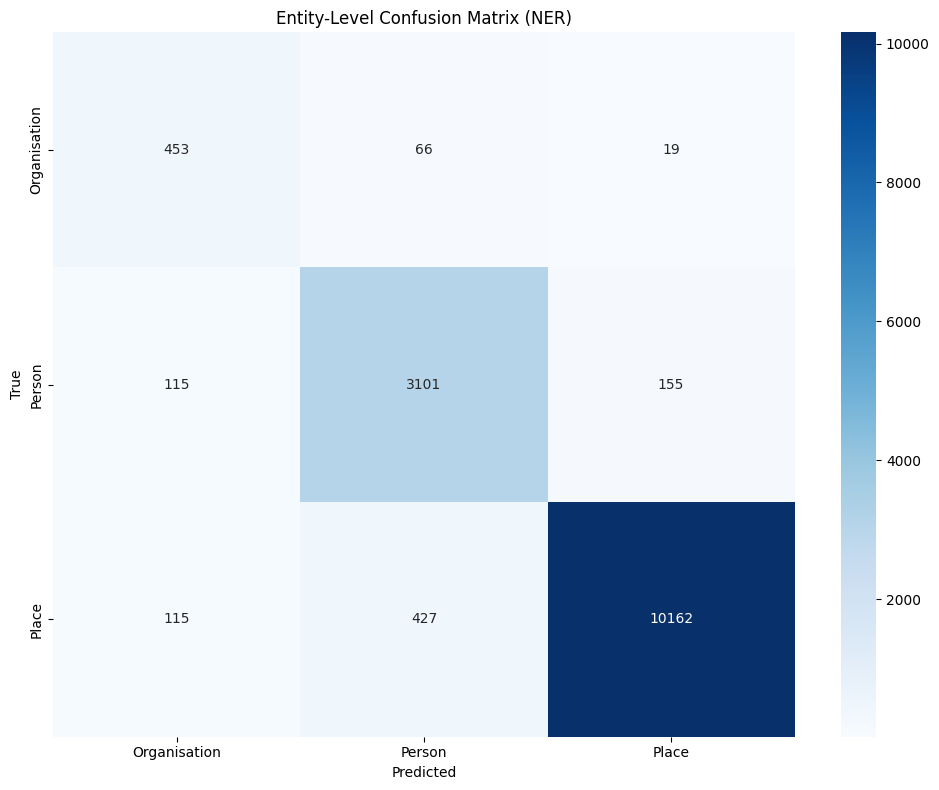

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=entity_labels,
            yticklabels=entity_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Entity-Level Confusion Matrix (NER)")
plt.tight_layout()
plt.show()


Bagian ini memvisualisasikan confusion matrix dalam bentuk heatmap menggunakan seaborn, sehingga lebih mudah melihat pola kesalahan prediksi model. Output berupa grafik heatmap berukuran 10x8 dengan skema warna biru, di mana warna yang lebih gelap menunjukkan frekuensi yang lebih tinggi. Angka pada setiap sel menunjukkan jumlah prediksi, nilai diagonal yang besar (warna gelap) menunjukkan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan confusion antar kelas entitas (misalnya Person diprediksi sebagai Place).

In [20]:
from seqeval.metrics import precision_score, recall_score, f1_score

micro_p = precision_score(true_entities, pred_entities, average="micro")
micro_r = recall_score(true_entities, pred_entities, average="micro")
micro_f1 = f1_score(true_entities, pred_entities, average="micro")

macro_p = precision_score(true_entities, pred_entities, average="macro")
macro_r = recall_score(true_entities, pred_entities, average="macro")
macro_f1 = f1_score(true_entities, pred_entities, average="macro")

weighted_p = precision_score(true_entities, pred_entities, average="weighted")
weighted_r = recall_score(true_entities, pred_entities, average="weighted")
weighted_f1 = f1_score(true_entities, pred_entities, average="weighted")

print("\n=== Macro/Micro/Weighted Metrics ===")
print("Micro F1 :", round(micro_f1, 4))
print("Macro F1 :", round(macro_f1, 4))
print("Weighted F1 :", round(weighted_f1, 4))



=== Macro/Micro/Weighted Metrics ===
Micro F1 : 0.417
Macro F1 : 0.386
Weighted F1 : 0.4344


Bagian ini menghitung metrik evaluasi dengan tiga metode agregasi berbeda: micro (menghitung total TP/FP/FN dari semua kelas), macro (rata-rata metrik per kelas tanpa mempertimbangkan proporsi), dan weighted (rata-rata metrik per kelas dengan bobot sesuai jumlah sample). Output menampilkan tiga nilai F1-score: Micro F1 yang lebih dipengaruhi kelas mayoritas, Macro F1 yang memberikan bobot sama untuk semua kelas sehingga lebih sensitif terhadap performa pada kelas minoritas, dan Weighted F1 yang menyeimbangkan keduanya dengan mempertimbangkan distribusi kelas di dataset.

In [21]:
import pandas as pd

error_data = []
for i, lab in enumerate(entity_labels):
    total = cm[i].sum()
    correct = cm[i][i]
    wrong = total - correct
    error_rate = wrong / total if total > 0 else 0

    error_data.append({
        "Label": lab,
        "Support": total,
        "Correct": correct,
        "Wrong": wrong,
        "Error Rate": round(error_rate, 4)
    })

df_error = pd.DataFrame(error_data)
print("\n=== Error Rate per Entity ===")
print(df_error)



=== Error Rate per Entity ===
          Label  Support  Correct  Wrong  Error Rate
0  Organisation      538      453     85      0.1580
1        Person     3371     3101    270      0.0801
2         Place    10704    10162    542      0.0506


Bagian ini menghitung error rate per jenis entitas berdasarkan confusion matrix, menampilkan berapa total support (jumlah entitas), berapa yang diprediksi benar, berapa yang salah, dan persentase kesalahannya. Output berupa tabel DataFrame dengan kolom Label, Support, Correct, Wrong, dan Error Rate untuk setiap jenis entitas (Organisation, Person, Place). Tabel ini membantu mengidentifikasi jenis entitas mana yang paling sulit diprediksi oleh model (error rate tinggi) dan bisa menjadi fokus perbaikan di iterasi berikutnya.

In [22]:
torch.save(model.state_dict(), "/kaggle/working/NER_IndoELECTRA.pth")
print("Model saved to /kaggle/working/NER_IndoELECTRA.pth")


Model saved to /kaggle/working/NER_IndoELECTRA.pth


Bagian ini menyimpan state_dict model yang sudah dilatih ke file .pth untuk digunakan kembali di masa depan tanpa perlu training ulang. File ini berisi seluruh bobot dan parameter model yang telah di-fine-tune untuk task NER pada dataset SINGGALANG. Output menampilkan pesan konfirmasi "Model saved to /kaggle/working/NER_IndoELECTRA.pth" yang menunjukkan bahwa model berhasil disimpan ke lokasi yang ditentukan.